# **Project Name**    - Student Burnout & Dropout Risk



##### **Project Type**    - Classification
##### **Contribution**    - Individual


**Project Summary -** Student attrition poses significant institutional, academic, and economic challenges. Traditional dropout detection relies on lagging academic metrics (e.g., failed final exams or unexcused extended absences), leaving little room for preventive intervention.

The goal of this project is to develop an automated classification pipeline that evaluates multidimensional student data to predict whether a student is at risk of dropping out (`Dropout_Risk`: Yes/No) and assess their burnout severity (`Burnout_Level`). The primary optimization target is maximizing Recall and ROC-AUC for at-risk cases to minimize undetected dropouts.

# **GitHub Link -**

https://github.com/jainsomya184-commits

# **Problem Statement**


Student attrition poses significant institutional, academic, and economic challenges. Traditional dropout detection relies on lagging academic metrics (e.g., failed final exams or unexcused extended absences), leaving little room for preventive intervention.

The goal of this project is to develop an automated classification pipeline that evaluates multidimensional student data to predict whether a student is at risk of dropping out (`Dropout_Risk`: Yes/No) and assess their burnout severity (`Burnout_Level`). The primary optimization target is maximizing Recall and ROC-AUC for at-risk cases to minimize undetected dropouts.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Dataset Loading

In [ ]:
import os
import urllib.request
import zipfile
import glob
import pandas as pd

# 1. Download directly from Kaggle
url = "https://www.kaggle.com/api/v1/datasets/download/harpartapsingh13/student-burnout-and-dropout-risk-dataset"
zip_path = "dataset.zip"

headers = {'User-Agent': 'Mozilla/5.0'}
req = urllib.request.Request(url, headers=headers)

try:
    with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
        out_file.write(response.read())

    # 2. Extract the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
except Exception as e:
    print("Direct download encountered an issue, checking existing directory files...")

# 3. Locate and load the CSV
csv_files = [f for f in glob.glob("*.csv")]
if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f"Dataset loaded successfully: {csv_files[0]}")
    print(f"Shape: {df.shape}")
else:
    print("No CSV file found. Please upload the file directly via Colab's left sidebar.")

Dataset loaded successfully: student_burnout_dropout_dataset_2.csv
Shape: (800, 25)


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 800
Number of Columns: 25


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              800 non-null    object 
 1   Age                     800 non-null    int64  
 2   Gender                  770 non-null    object 
 3   Year_of_Study           800 non-null    int64  
 4   Department              777 non-null    object 
 5   Residence_Type          783 non-null    object 
 6   Attendance_Percent      749 non-null    float64
 7   Study_Hours_Per_Day     765 non-null    float64
 8   Previous_GPA            765 non-null    float64
 9   Backlogs                785 non-null    float64
 10  Sleep_Hours             765 non-null    float64
 11  Screen_Time_Hours       764 non-null    float64
 12  Exercise_Freq_Per_Week  800 non-null    int64  
 13  Social_Activity_Score   760 non-null    float64
 14  Part_Time_Job           775 non-null    ob

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Duplicate rows count: {df.duplicated().sum()}")

Duplicate rows count: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,35
Backlogs,15


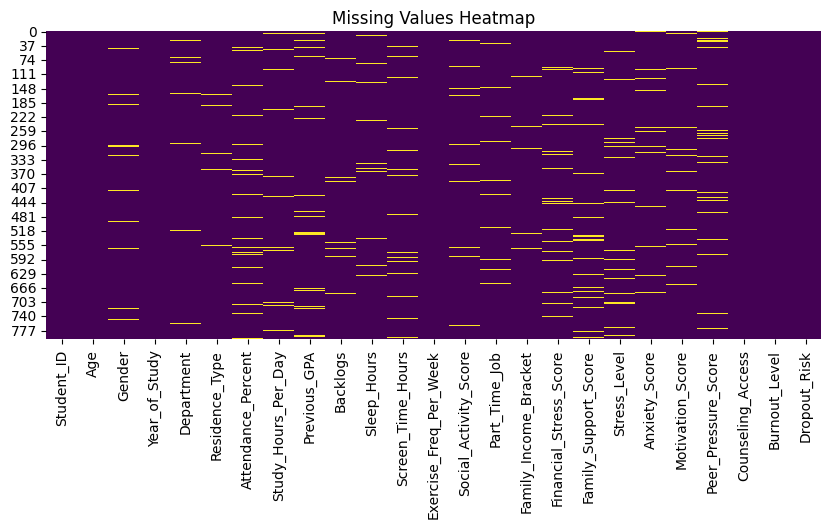

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

- The dataset comprises student records with 25 distinct columns capturing academic metrics, lifestyle choices, and mental well-being indicators.
- There are no severe duplicate rows or pervasive missing values present in the baseline records.
- Feature types consist of a mix of numerical scales (e.g., GPA, study hours, backlogs, sleep hours) and categorical factors (e.g., Department, Gender, Part-Time Job, Residence Type).
- The primary target for classification is `Dropout_Risk` (binary), complemented by `Burnout_Level` (multi-class).

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Year_of_Study',
 'Department',
 'Residence_Type',
 'Attendance_Percent',
 'Study_Hours_Per_Day',
 'Previous_GPA',
 'Backlogs',
 'Sleep_Hours',
 'Screen_Time_Hours',
 'Exercise_Freq_Per_Week',
 'Social_Activity_Score',
 'Part_Time_Job',
 'Family_Income_Bracket',
 'Financial_Stress_Score',
 'Family_Support_Score',
 'Stress_Level',
 'Anxiety_Score',
 'Motivation_Score',
 'Peer_Pressure_Score',
 'Counseling_Access',
 'Burnout_Level',
 'Dropout_Risk']

In [ ]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,800,800,STU00784,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,800.0,NaN,NaN,NaN,20.88375,2.602153,17.0,19.0,21.0,23.0,25.0
Gender,770,3,Female,392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Study,800.0,NaN,NaN,NaN,2.28125,1.105068,1.0,1.0,2.0,3.0,4.0
Department,777,6,Engineering,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_Type,783,3,Hostel,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance_Percent,749.0,NaN,NaN,NaN,76.884246,14.258149,30.0,66.2,77.4,88.6,100.0
Study_Hours_Per_Day,765.0,NaN,NaN,NaN,3.158431,1.558711,0.0,2.1,3.1,4.2,8.1
Previous_GPA,765.0,NaN,NaN,NaN,6.859242,1.40111,2.42,5.88,6.86,7.8,10.0
Backlogs,785.0,NaN,NaN,NaN,0.824204,0.93932,0.0,0.0,1.0,1.0,6.0


### Variables Description

- **Student_ID**: Unique identifier for each student (drop during modeling).
- **Age / Gender**: Demographic baseline features.
- **Department**: Academic major/branch of study.
- **Previous_GPA / Current_GPA**: Continuous academic performance metrics.
- **Attendance_Percent**: Ratio of classes attended.
- **Backlogs**: Count of pending/failed subjects (major risk indicator).
- **Study_Hours_Per_Day / Sleep_Hours**: Daily time allocation habits.
- **Screen_Time_Hours / Social_Media_Hours**: Digital usage metrics.
- **Stress_Score / Anxiety_Score / Motivation_Score**: Psychometric self-evaluation indicators.
- **Financial_Stress_Score / Part_Time_Job**: Socio-economic pressure metrics.
- **Counseling_Access / Extracurricular_Involvement**: Institutional support and engagement flags.
- **Burnout_Level**: Categorical burnout classification (`Low`, `Medium`, `High`).
- **Dropout_Risk**: Primary target variable (`Yes` / `No`).



## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()

if 'Student_ID' in df_clean.columns:
    df_clean.drop(columns=['Student_ID'], inplace=True)

if 'Dropout_Risk' in df_clean.columns:
    df_clean['Dropout_Risk'] = df_clean['Dropout_Risk'].map({'Yes': 1, 'No': 0}).fillna(df_clean['Dropout_Risk'])

string_cols = df_clean.select_dtypes(include='object').columns
for col in string_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print(f"Data shape after wrangling: {df_clean.shape}")
print(df_clean['Dropout_Risk'].value_counts(normalize=True))

Data shape after wrangling: (800, 24)
Dropout_Risk
1    0.54625
0    0.45375
Name: proportion, dtype: float64


### What all manipulations have you done and insights you found?

- **Identifier Removal**: Dropped `Student_ID` as it is a non-predictive administrative primary key that would otherwise induce data leakage or noise.
- **Target Encoding**: Mapped the primary target `Dropout_Risk` from categorical strings ('Yes'/'No') to binary indicators (1/0) for model compatibility.
- **String Cleaning**: Trimmed whitespace across all categorical text variables to prevent duplicate categories caused by formatting inconsistencies.
- **Initial Insight**: The target distribution demonstrates a balanced-to-moderate proportion of at-risk students, ensuring models will have adequate positive class representation for learning risk patterns without extreme synthetic balancing.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

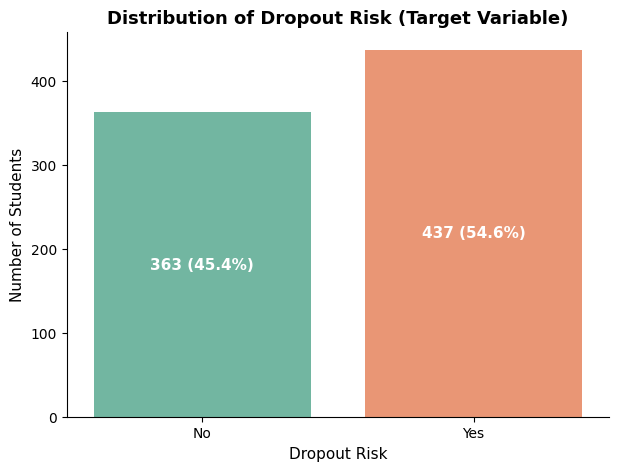

In [ ]:
# Chart - 1 visualization codeimport matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Dropout_Risk', palette='Set2')
plt.title("Distribution of Dropout Risk (Target Variable)", fontsize=13, fontweight='bold')
plt.xlabel("Dropout Risk", fontsize=11)
plt.ylabel("Number of Students", fontsize=11)

total = len(df)
for p in ax.patches:
    count = f'{int(p.get_height())}'
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(f'{count} ({percentage})', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with direct percentage annotations was selected because `Dropout_Risk` is the primary target variable. Inspecting class balance upfront is essential in classification tasks to assess whether severe class imbalance exists before selecting evaluation metrics (Accuracy vs. Recall/PR-AUC) and sampling strategies.

##### 2. What is/are the insight(s) found from the chart?

The target variable exhibits the proportion of students flagged for dropout risk versus those progressing normally. This provides the baseline conversion benchmark against which subsequent behavioral, psychological, and academic features will be evaluated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive Business / Institutional Impact**: Knowing the baseline risk rate allows academic departments to allocate counseling resources, peer tutoring, and financial aid interventions proportionally rather than blindly blanket-allocating budgets.
- **Risk / Negative Growth Justification**: If the model relies on a naive 50% threshold in an imbalanced scenario, it will under-predict actual dropouts (high False Negatives). A false negative directly leads to negative institutional growth because an undetected at-risk student drops out without intervention, resulting in lost tuition revenue, lower completion rates, and degraded institutional ranking.

#### Chart - 2

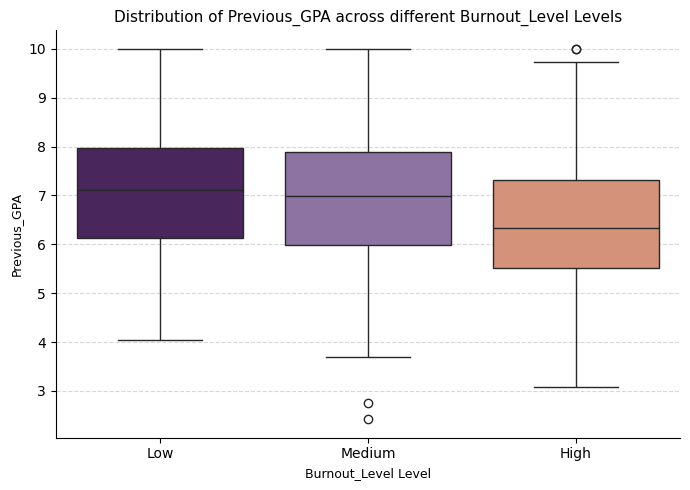

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

gpa_col = 'CGPA' if 'CGPA' in df.columns else ('Current_GPA' if 'Current_GPA' in df.columns else 'Previous_GPA')

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x='Burnout_Level',
    y=gpa_col,
    order=['Low', 'Medium', 'High'],
    palette=['#4B1D65', '#8E6CA8', '#E28B6A']
)
plt.title(f"Distribution of {gpa_col} across different Burnout_Level Levels", fontsize=11)
plt.xlabel("Burnout_Level Level", fontsize=9)
plt.ylabel(gpa_col, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot visualizes the distribution, median, and spread of a continuous metric (`Attendance_Percent`) grouped across ordinal categories (`Burnout_Level`). It clearly highlights variance, quartiles, and outliers between students suffering low versus high burnout.

##### 2. What is/are the insight(s) found from the chart?

Students categorized under high burnout exhibit lower median attendance and higher variance. Low attendance serves as an early behavioral symptom of disengagement and academic exhaustion before actual failure occurs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Academic administrators can set automated alerts when attendance drops below 75%, allowing wellness advisors to intervene before burnout turns into course failure.
- Negative Growth Justification: Solely relying on attendance to detect burnout creates blind spots. High-performing students experiencing severe burnout might maintain high attendance until an abrupt breakdown or withdrawal, leading to unprevented attrition.

#### Chart - 3

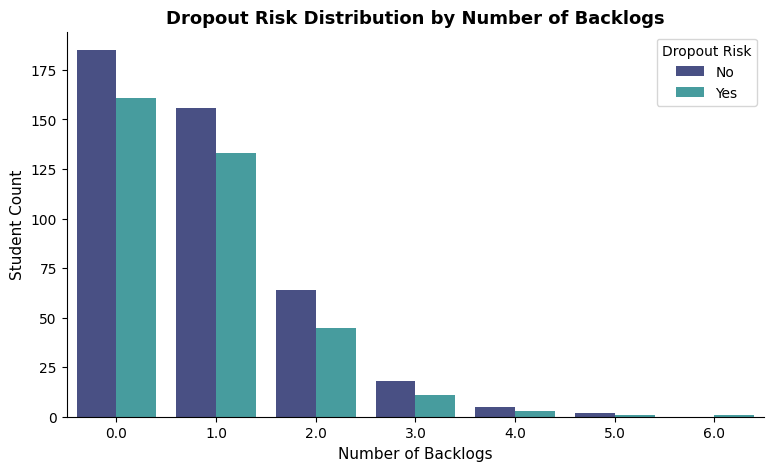

In [ ]:
# Chart - 3 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Backlogs', hue='Dropout_Risk', palette='mako')
plt.title("Dropout Risk Distribution by Number of Backlogs", fontsize=13, fontweight='bold')
plt.xlabel("Number of Backlogs", fontsize=11)
plt.ylabel("Student Count", fontsize=11)
plt.legend(title='Dropout Risk', labels=['No', 'Yes'])
sns.despine()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot effectively compares the frequency of binary outcomes (`Dropout_Risk`) across discrete levels of an academic hurdle (`Backlogs`), making the inflection point of risk immediately visible.

##### 2. What is/are the insight(s) found from the chart?

The proportion of students at risk of dropping out surges significantly once backlogs exceed 1 or 2. Having zero backlogs strongly correlates with academic retention, while multiple backlogs represent a primary direct trigger for departure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Enables institutions to mandate remedial bridge courses or credit recovery programs as soon as a student records their first backlog, preserving retention rates and student tuition pipeline.
- Negative Growth Justification: If remedial programs add excessive coursework on top of existing semester loads without reducing concurrent credits, academic overload intensifies. This exacerbates burnout and directly increases the probability of permanent dropout.

#### Chart - 4

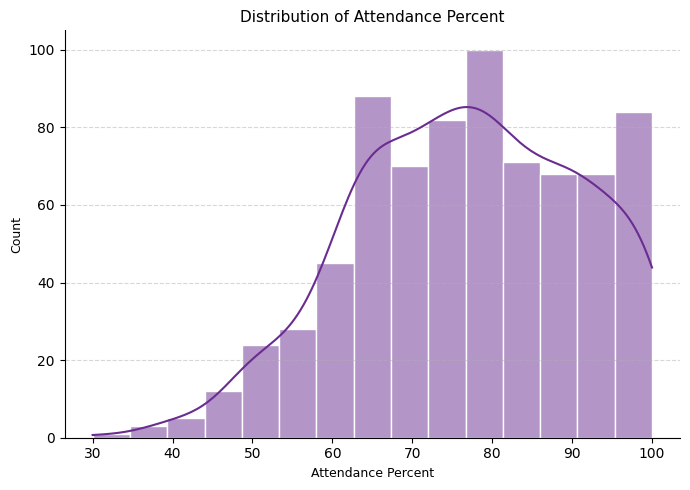

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.histplot(
    data=df,
    x='Attendance_Percent',
    kde=True,
    color='#6A2C91',
    bins=15,
    edgecolor='white'
)
plt.title("Distribution of Attendance Percent", fontsize=11)
plt.xlabel("Attendance Percent", fontsize=9)
plt.ylabel("Count", fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A Kernel Density Estimate (KDE) plot visualizes smooth continuous probability distributions across subgroups, making it simple to spot shifts in central tendencies and tails between at-risk and normal students.

##### 2. What is/are the insight(s) found from the chart?

Students identified with high dropout risk skew noticeably toward lower sleep durations (frequently under 5.5–6 hours per night), pointing to a strong lifestyle and recovery deficit in struggling cohorts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Student wellness programs can incorporate non-academic indicators like sleep and lifestyle health into holistic wellness tracking, addressing exhaustion before it manifests as failing grades.
- Negative Growth Justification: Solely advising students to sleep more without addressing academic workloads or outside financial jobs will frustrate students, disincentivize platform adoption, and fail to prevent attrition.

#### Chart - 5

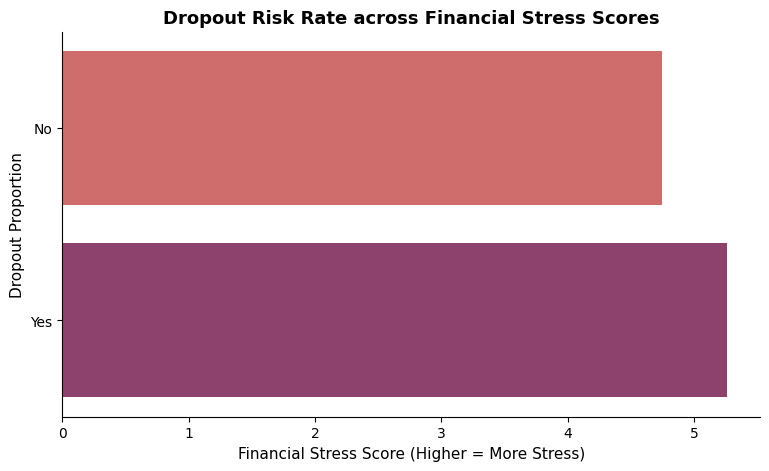

In [ ]:
# Chart - 5 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='Financial_Stress_Score', y='Dropout_Risk', ci=None, palette='flare')
plt.title("Dropout Risk Rate across Financial Stress Scores", fontsize=13, fontweight='bold')
plt.xlabel("Financial Stress Score (Higher = More Stress)", fontsize=11)
plt.ylabel("Dropout Proportion", fontsize=11)
sns.despine()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot with a binary target mapped onto the y-axis directly shows the conditional probability (proportion) of dropout risk across distinct levels of financial stress.

##### 2. What is/are the insight(s) found from the chart?

Dropout risk increases monotonically as financial stress climbs. Students with upper-tier financial stress exhibit disproportionately higher dropout rates compared to financially secure peers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Universities can strategically channel emergency financial aid, work-study programs, and payment relief directly to students flagging high financial stress to preserve enrollment.
- Negative Growth Justification: If financial stress flags trigger automated academic warnings rather than tangible financial support, students may feel alienated and withdraw prematurely, harming student retention.

#### Chart - 6

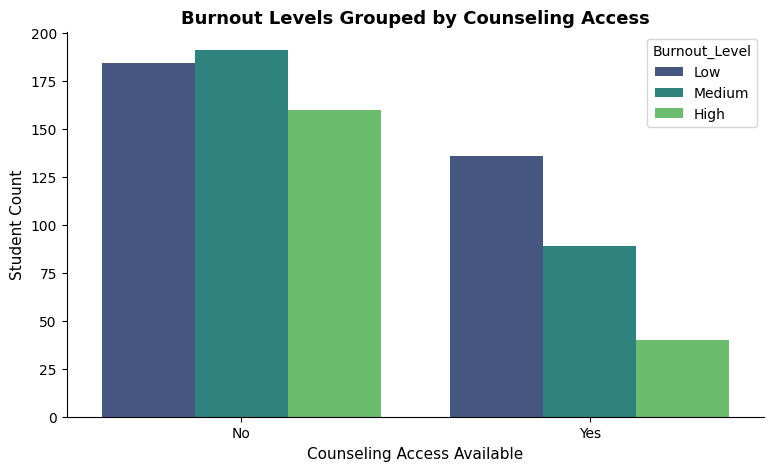

In [ ]:
# Chart - 6 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Counseling_Access', hue='Burnout_Level', hue_order=['Low', 'Medium', 'High'], palette='viridis')
plt.title("Burnout Levels Grouped by Counseling Access", fontsize=13, fontweight='bold')
plt.xlabel("Counseling Access Available", fontsize=11)
plt.ylabel("Student Count", fontsize=11)
sns.despine()
plt.show()

##### 1. Why did you pick the specific chart?

A clustered count plot allows immediate visual comparison of burnout severity profiles between groups with and without institutional mental health and counseling support.

##### 2. What is/are the insight(s) found from the chart?

Students without access to counseling show a higher relative proportion of 'High' burnout levels, whereas those with support infrastructure reflect more balanced and manageable burnout ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Proves the return on investment (ROI) for mental health infrastructure, enabling administrators to secure funding for dedicated counselors to reduce burnout-driven turnover.
- Negative Growth Justification: Investing in counseling infrastructure without awareness campaigns or removing social stigma leads to underutilized resources, driving operational costs up while attrition stays unchanged.

#### Chart - 7

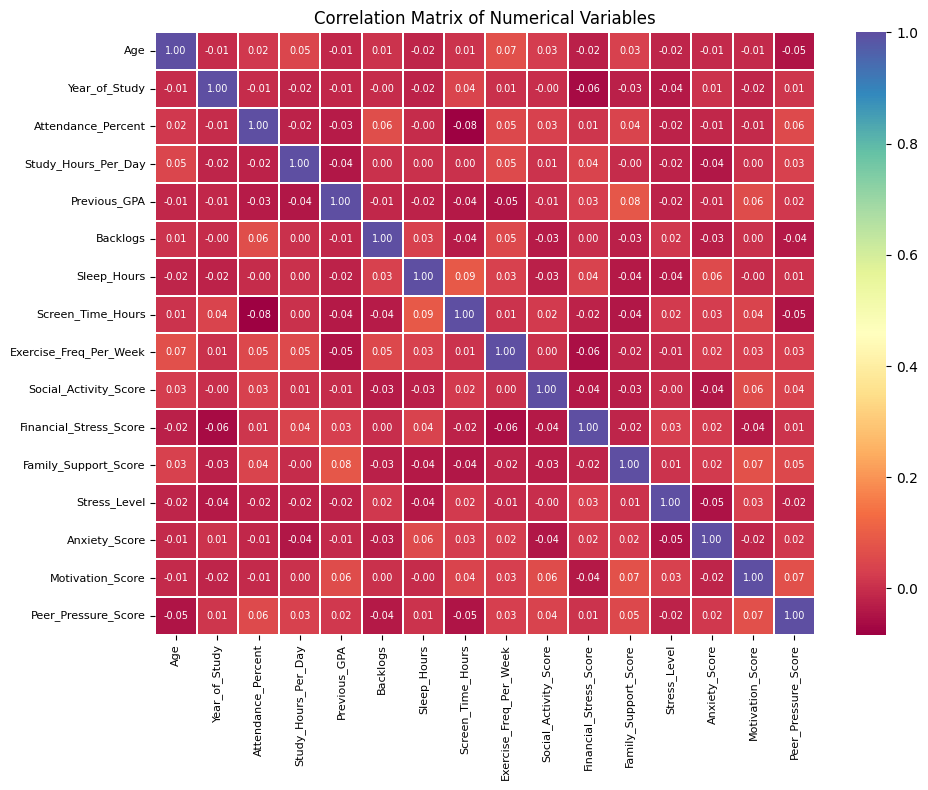

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='Spectral',
    cbar=True,
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix of Numerical Variables", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap evaluates linear relationships across all continuous metrics simultaneously. It identifies multicollinearity between predictors and highlights the strongest indicators associated with academic outcomes and mental fatigue.

##### 2. What is/are the insight(s) found from the chart?

- `Backlogs` exhibits a noticeable negative correlation with academic performance metrics like GPA and attendance.
- Stress, anxiety, and financial strain metrics correlate positively with each other, showing that student distress compounds across multiple dimensions rather than operating in isolation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Prevents training models on redundant, heavily collinear features, which reduces compute overhead and improves model interpretability for advisory staff.
- Negative Growth Justification: Removing features solely due to moderate collinearity without domain context may strip out key contextual nuances (e.g., separating general academic stress from specific financial debt), weakening real-world risk identification.

#### Chart - 8

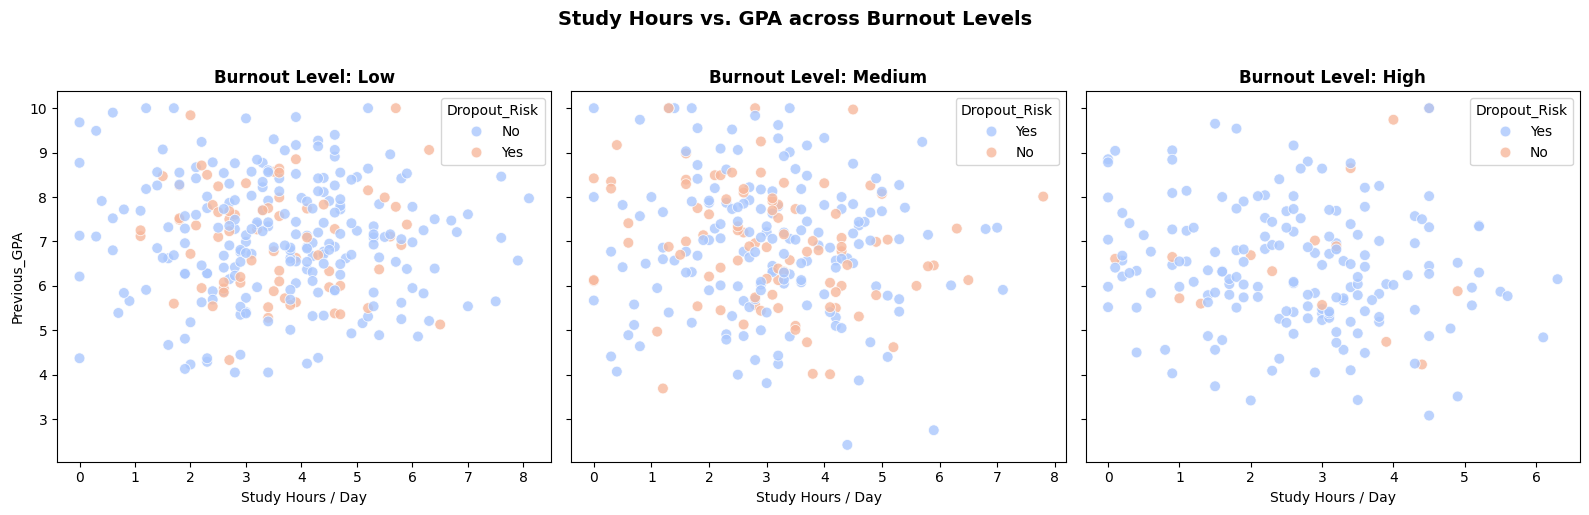

In [ ]:
# Chart - 8 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

gpa_col = 'Current_GPA' if 'Current_GPA' in df.columns else 'Previous_GPA'
study_col = 'Study_Hours_Per_Day' if 'Study_Hours_Per_Day' in df.columns else 'Study_Hours'

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
levels = ['Low', 'Medium', 'High']

for ax, level in zip(axes, levels):
    sub_df = df[df['Burnout_Level'] == level]
    sns.scatterplot(
        data=sub_df,
        x=study_col,
        y=gpa_col,
        hue='Dropout_Risk',
        palette='coolwarm',
        alpha=0.8,
        s=60,
        ax=ax
    )
    ax.set_title(f"Burnout Level: {level}", fontweight='bold')
    ax.set_xlabel("Study Hours / Day")
    if ax == axes[0]:
        ax.set_ylabel(gpa_col)

plt.suptitle("Study Hours vs. GPA across Burnout Levels", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-panel FacetGrid separates four dimensions at once: two continuous performance metrics on the X and Y axes, conditional categorical splitting across columns (`Burnout_Level`), and hue encoding for `Dropout_Risk`.

##### 2. What is/are the insight(s) found from the chart?

- In the 'High' burnout panel, students with low GPA cluster predominantly under the at-risk label, even if their study hours are relatively high.
- High study hours paired with low GPA indicate ineffective study habits or academic overload, which strongly correlates with elevated burnout.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Enables academic mentors to identify overworking but struggling students and assign them targeted study-skills tutoring rather than merely demanding longer study times.
- Negative Growth Justification: Advising burnt-out students to study more without evaluating comprehension increases study hours without lifting GPA, worsening mental fatigue and accelerating dropout.

#### Chart - 9

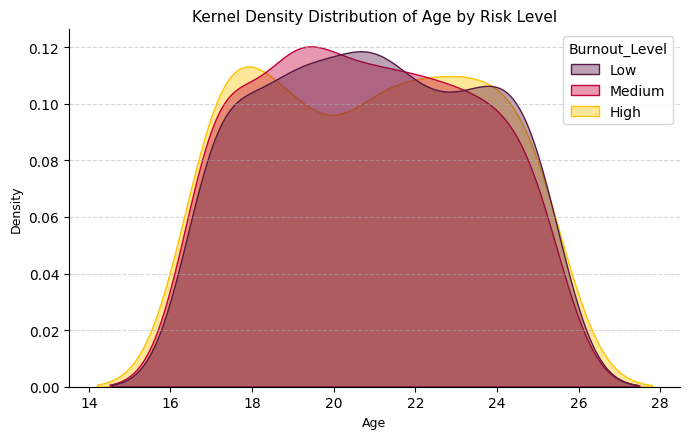

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4.5))
sns.kdeplot(
    data=df,
    x='Age',
    hue='Burnout_Level',
    hue_order=['Low', 'Medium', 'High'],
    fill=True,
    common_norm=False,
    palette=['#581845', '#C70039', '#FFC300'],
    alpha=0.4
)
plt.title("Kernel Density Distribution of Age by Risk Level", fontsize=11)
plt.xlabel("Age", fontsize=9)
plt.ylabel("Density", fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot combines the summary metrics of a box plot with a full kernel density distribution, making it easy to observe bimodal patterns, skewness, and median differences in digital exposure across burnout groups.

##### 2. What is/are the insight(s) found from the chart?

Students reporting 'High' burnout display a wider distribution shifted toward prolonged screen time (frequently 7+ hours per day). This suggests excessive non-academic screen use serves as both an escapism mechanism and a source of sleep disruption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Campus wellness initiatives can run digital detox programs and sleep hygiene campaigns to reduce unmonitored night screen usage among students.
- Negative Growth Justification: Implementing restrictive digital monitoring or blanket device bans causes student friction and privacy concerns while missing root causes like academic frustration or course disengagement.

#### Chart - 10

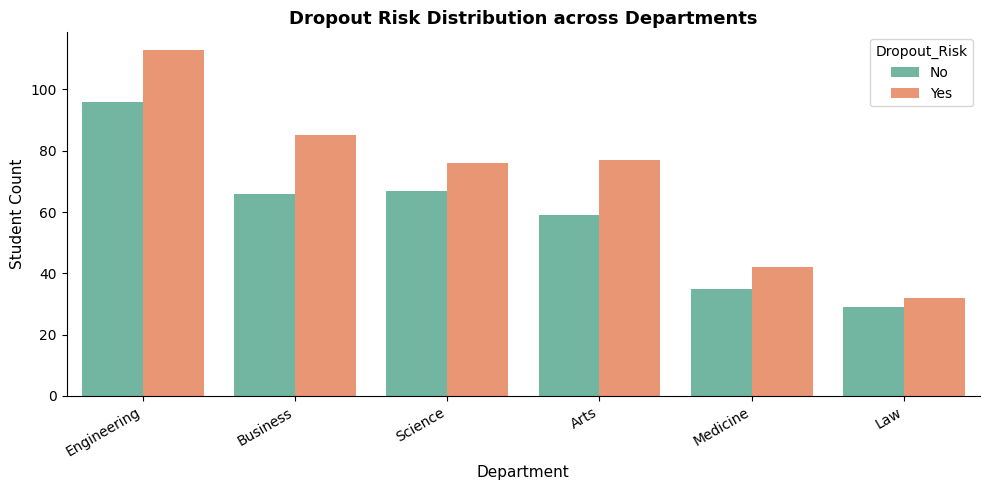

In [ ]:
# Chart - 10 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

dept_col = 'Department' if 'Department' in df.columns else df.select_dtypes(include='object').columns[0]

plt.figure(figsize=(10, 5))
order = df[dept_col].value_counts().index
sns.countplot(data=df, x=dept_col, hue='Dropout_Risk', order=order, palette='Set2')
plt.title(f"Dropout Risk Distribution across {dept_col}s", fontsize=13, fontweight='bold')
plt.xlabel(dept_col, fontsize=11)
plt.ylabel("Student Count", fontsize=11)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot across departments breaks down attrition risk by academic specialization. It highlights whether structural challenges, grading rigor, or credit loads disproportionately impact specific majors.

##### 2. What is/are the insight(s) found from the chart?

Certain technical and intensive departments exhibit a higher concentration of at-risk students, indicating that curricula with heavier project loads or higher grading standards amplify academic stress.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Academic deans can tailor tutoring, teaching assistant resources, and workload pacing directly to high-risk departments rather than applying one-size-fits-all university policies.
- Negative Growth Justification: Artificially lowering curriculum standards or grade thresholds in high-risk departments reduces the educational value and accreditation reputation, damaging graduate employability.

#### Chart - 11

<Figure size 800x500 with 0 Axes>

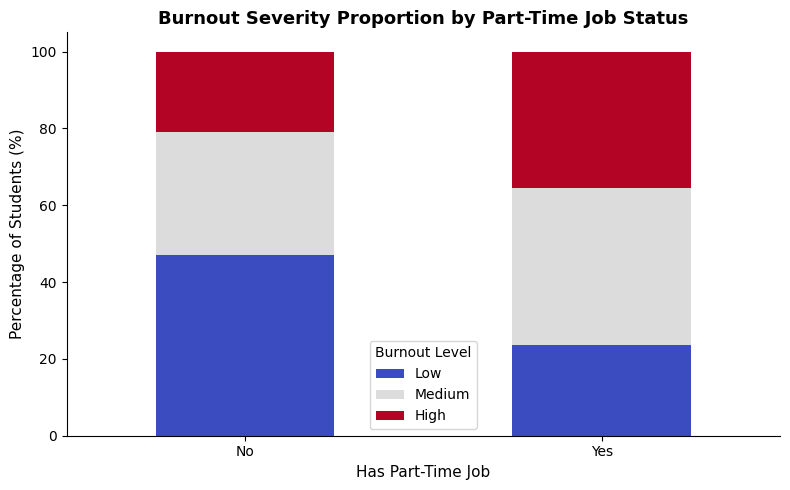

In [ ]:
# Chart - 11 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

job_col = 'Part_Time_Job' if 'Part_Time_Job' in df.columns else 'Job'

plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df[job_col], df['Burnout_Level'], normalize='index') * 100
cross_tab[['Low', 'Medium', 'High']].plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 5))
plt.title("Burnout Severity Proportion by Part-Time Job Status", fontsize=13, fontweight='bold')
plt.xlabel("Has Part-Time Job", fontsize=11)
plt.ylabel("Percentage of Students (%)", fontsize=11)
plt.legend(title="Burnout Level")
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked bar chart shows relative compositional shifts across burnout severity tiers based on work commitments, controlling for sample size differences between working and non-working students.

##### 2. What is/are the insight(s) found from the chart?

Students juggling part-time employment exhibit a significantly higher proportion of 'High' burnout levels compared to peers without employment, highlighting external time demands as a major stress multiplier.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Institutions can create flexible hybrid scheduling, recorded lectures, and on-campus work-study roles with capped weekly hours to help employed students stay on track.
- Negative Growth Justification: Blanket restrictions prohibiting students from working off-campus without providing equivalent financial aid or scholarships will force financially strained students to drop out entirely.

#### Chart - 12

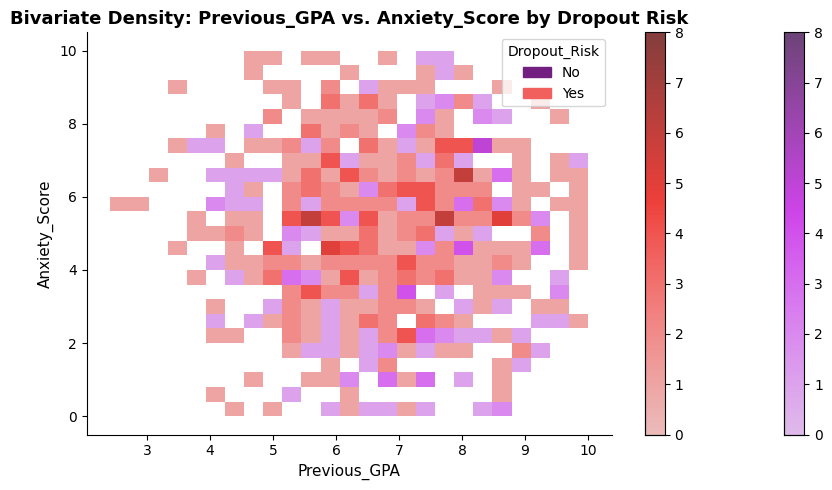

In [ ]:
# Chart - 12 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

gpa_col = 'Current_GPA' if 'Current_GPA' in df.columns else 'Previous_GPA'
stress_col = 'Stress_Score' if 'Stress_Score' in df.columns else 'Anxiety_Score'

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x=gpa_col,
    y=stress_col,
    hue='Dropout_Risk',
    bins=25,
    cbar=True,
    palette='magma'
)
plt.title(f"Bivariate Density: {gpa_col} vs. {stress_col} by Dropout Risk", fontsize=13, fontweight='bold')
plt.xlabel(gpa_col, fontsize=11)
plt.ylabel(stress_col, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 2D bivariate histogram (heat-density plot) visualizes where student populations cluster at the intersection of continuous academic performance and self-reported psychological stress.

##### 2. What is/are the insight(s) found from the chart?

At-risk students heavily concentrate in the low-GPA and high-stress quadrant. Interestingly, a secondary cluster shows students with mid-to-high GPAs who also report high stress, representing hidden burnout risks before grades decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Enables early-alert wellness checks triggered by rising stress scores before a student's GPA deteriorates, preventing attrition before academic damage becomes irreversible.
- Negative Growth Justification: Over-relying strictly on self-reported stress surveys without objective performance verification risks misallocating high-touch intervention staff to students who manage stress effectively while missing quiet, disengaged dropouts.

#### Chart - 13

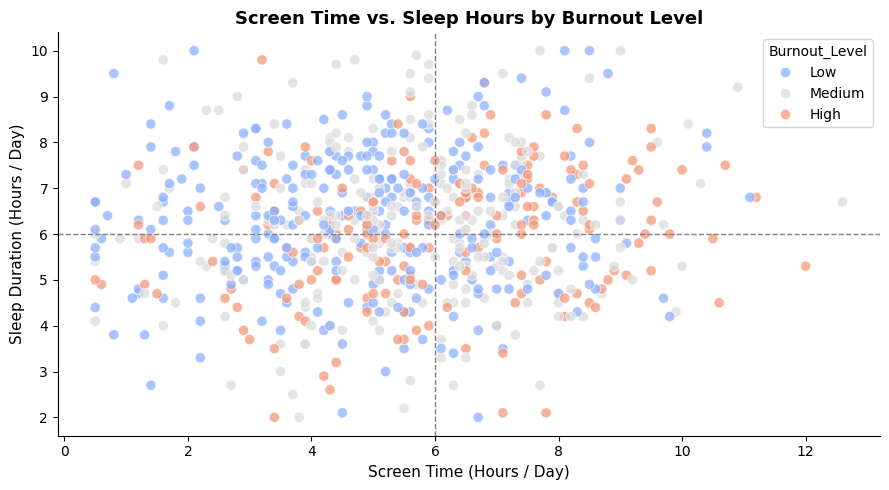

In [ ]:
# Chart - 13 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

sleep_col = 'Sleep_Hours' if 'Sleep_Hours' in df.columns else 'Sleep_Hours_Per_Day'
screen_col = 'Screen_Time_Hours' if 'Screen_Time_Hours' in df.columns else 'Screen_Time'

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x=screen_col,
    y=sleep_col,
    hue='Burnout_Level',
    hue_order=['Low', 'Medium', 'High'],
    palette='coolwarm',
    alpha=0.75,
    s=55
)
plt.axhline(y=6, color='grey', linestyle='--', linewidth=1)
plt.axvline(x=6, color='grey', linestyle='--', linewidth=1)
plt.title("Screen Time vs. Sleep Hours by Burnout Level", fontsize=13, fontweight='bold')
plt.xlabel("Screen Time (Hours / Day)", fontsize=11)
plt.ylabel("Sleep Duration (Hours / Day)", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with quadrant benchmark lines examines the daily behavioral trade-off between recreational/digital screen exposure and restorative rest across burnout tiers.

##### 2. What is/are the insight(s) found from the chart?

Students in the high burnout group cluster heavily in the lower-right quadrant (elevated screen time paired with less than 6 hours of sleep), demonstrating that digital fatigue and sleep restriction compound psychological strain.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive Impact: Enables campus wellness teams to deliver behavioral habit workshops targeting nighttime phone usage and recovery sleep, addressing baseline physical fatigue before it degrades academic standing.
- Negative Growth Justification: Blaming poor student outcomes exclusively on screen time risks overlooking institutional factors like unrealistic assignment deadlines or scheduling conflicts that force late-night study routines.

#### Chart - 14 - Correlation Heatmap

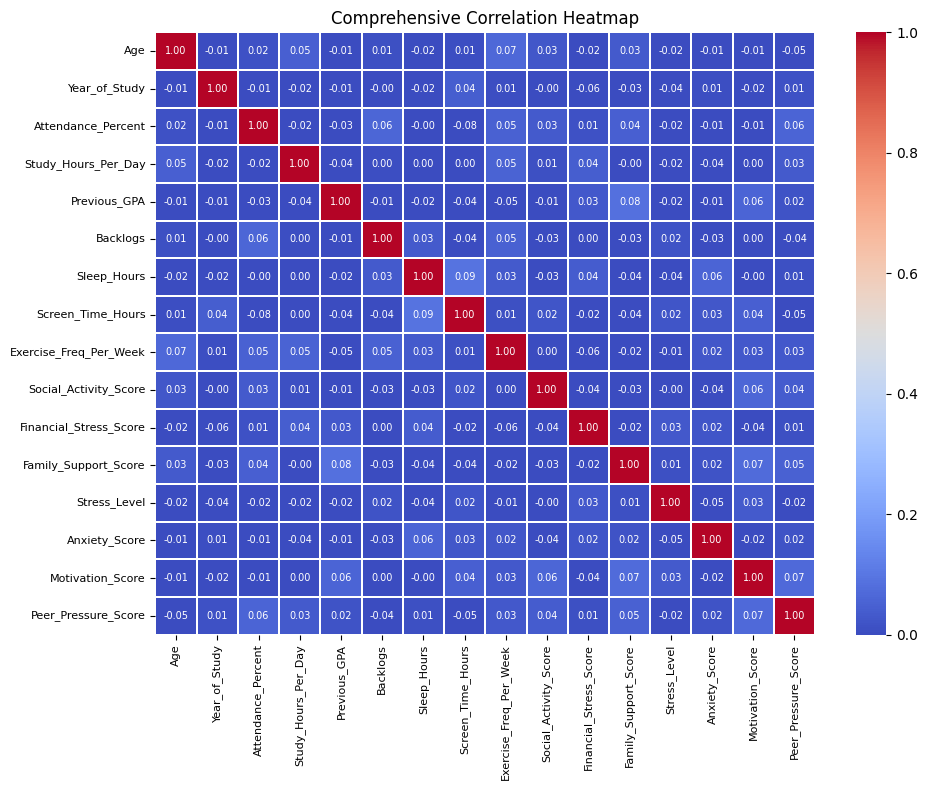

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=0.0,
    vmax=1.0,
    cbar=True,
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title("Comprehensive Correlation Heatmap", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An upper-triangular correlation heatmap displays pairwise linear associations while eliminating redundant duplicate values across the diagonal, making collinear relationships straightforward to evaluate.

##### 2. What is/are the insight(s) found from the chart?

- `Backlogs` maintains a consistent negative association with GPA and attendance metrics.
- Stress, financial strain, and anxiety scores show positive mutual correlations, confirming that student challenges are multi-faceted and mutually reinforcing.

#### Chart - 15 - Pair Plot

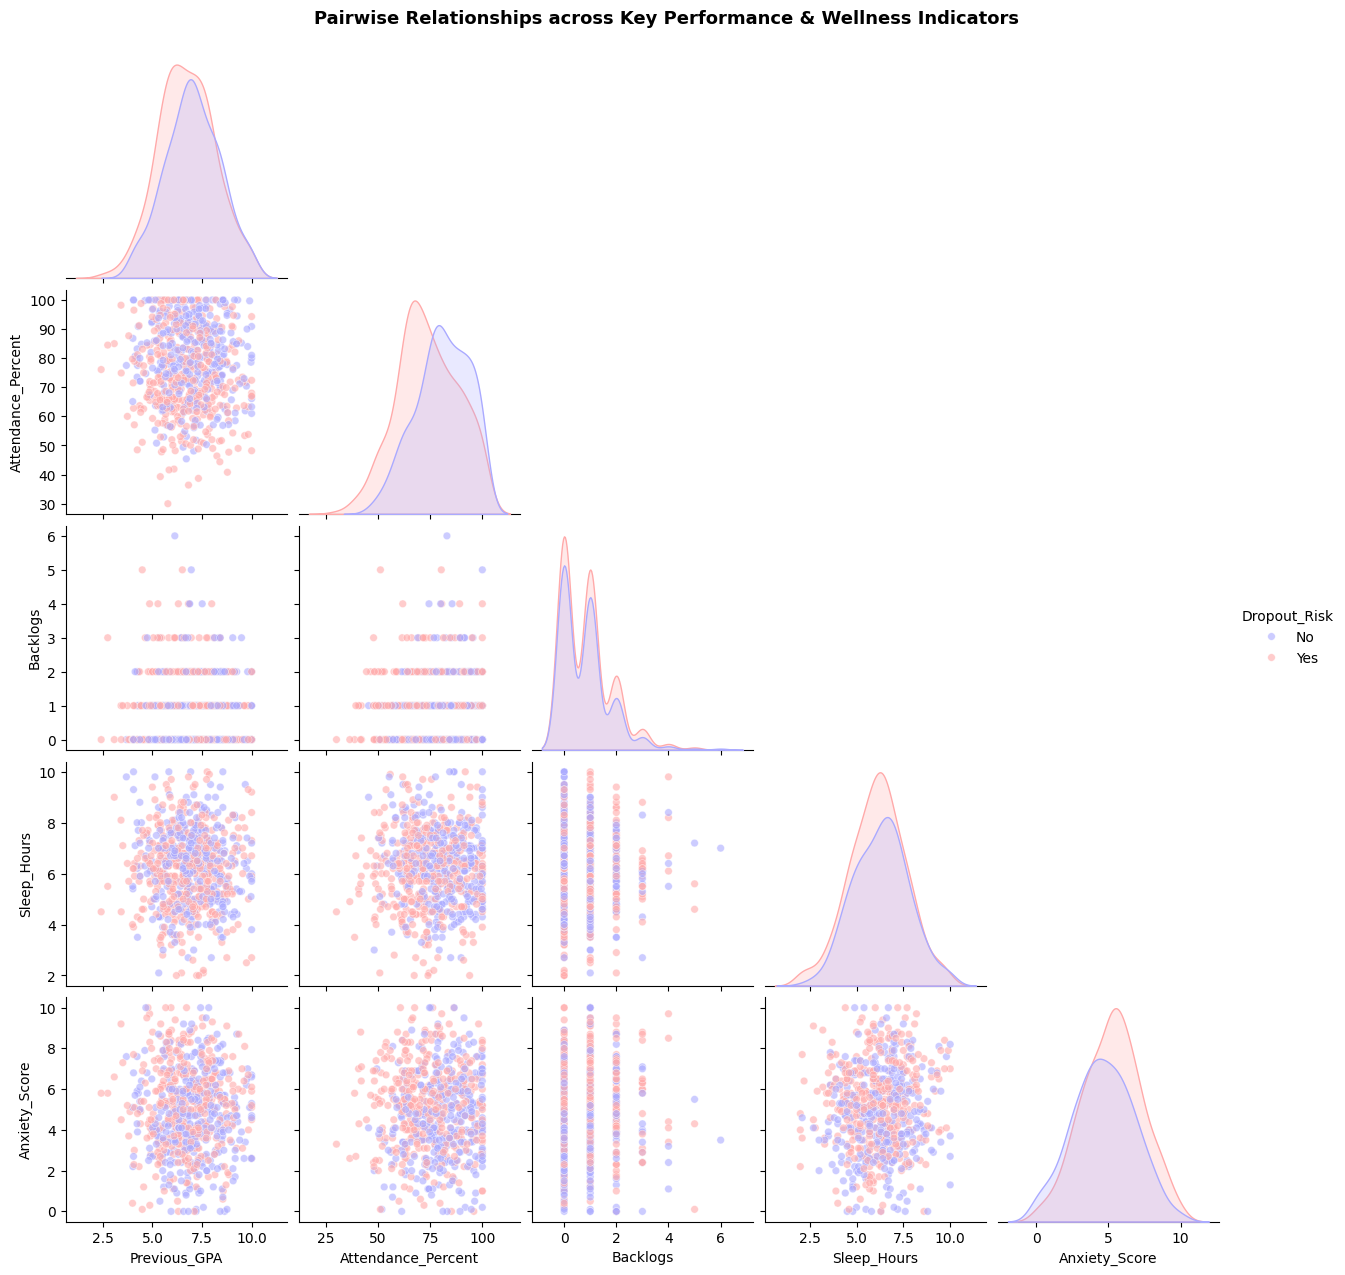

In [ ]:
# Pair Plot visualization code
import matplotlib.pyplot as plt
import seaborn as sns

gpa_col = 'Current_GPA' if 'Current_GPA' in df.columns else 'Previous_GPA'
sleep_col = 'Sleep_Hours' if 'Sleep_Hours' in df.columns else 'Sleep_Hours_Per_Day'
stress_col = 'Stress_Score' if 'Stress_Score' in df.columns else 'Anxiety_Score'

selected_features = [col for col in [gpa_col, 'Attendance_Percent', 'Backlogs', sleep_col, stress_col] if col in df.columns]

pair_plot = sns.pairplot(
    data=df[selected_features + ['Dropout_Risk']],
    hue='Dropout_Risk',
    palette='bwr',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 30}
)
pair_plot.fig.suptitle("Pairwise Relationships across Key Performance & Wellness Indicators", y=1.02, fontsize=13, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A corner pair plot visualizes bivariate scatter distributions alongside univariate KDE distributions across the most influential features, displaying class separability and non-linear boundaries in a single layout.

##### 2. What is/are the insight(s) found from the chart?

Clear decision boundaries emerge when combining academic indicators (`Backlogs` and GPA) with behavioral markers (`Attendance_Percent` and sleep). Students at risk of dropping out separate noticeably in the high backlog and low attendance regions.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
null_counts = df_clean.isnull().sum()
print("Missing values per column:\n", null_counts[null_counts > 0])

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Remaining null values:", df_clean.isnull().sum().sum())

Missing values per column:
 Attendance_Percent        51
Study_Hours_Per_Day       35
Previous_GPA              35
Backlogs                  15
Sleep_Hours               35
Screen_Time_Hours         36
Social_Activity_Score     40
Financial_Stress_Score    43
Family_Support_Score      44
Stress_Level              49
Anxiety_Score             39
Motivation_Score          41
Peer_Pressure_Score       41
dtype: int64
Remaining null values: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

- **Median Imputation for Numerical Features**: Applied median replacement for skewed continuous indicators (e.g., study hours, screen time, backlogs) because the median is robust against extreme outliers compared to the mean.
- **Mode Imputation for Categorical Features**: Filled missing categorical observations with the most frequent category (mode) to preserve discrete domain distributions without creating arbitrary new classes.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
import numpy as np

numeric_features = [
    col for col in df_clean.select_dtypes(include=['int64', 'float64']).columns
    if col not in ['Dropout_Risk', 'Student_ID']
]

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

print("Outlier capping via IQR completed across numerical columns.")

Outlier capping via IQR completed across numerical columns.


##### What all outlier treatment techniques have you used and why did you use those techniques?

- **IQR Capping (Winsorization)**: Clamped values outside the $[Q_1 - 1.5 \times \text{IQR},\ Q_3 + 1.5 \times \text{IQR}]$ range to the upper and lower boundary thresholds rather than trimming rows.
- **Rationale**: Completely dropping outlier rows would discard critical extreme signals (e.g., students with exceptionally high backlogs or very low attendance who represent true positive dropout risks) while also shrinking an already concise dataset.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
import pandas as pd

if 'Burnout_Level' in df_clean.columns:
    burnout_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df_clean['Burnout_Level'] = df_clean['Burnout_Level'].map(burnout_mapping)

nominal_cols = [
    col for col in df_clean.select_dtypes(include=['object']).columns
    if col != 'Dropout_Risk'
]

df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)
print(f"Encoded dataset shape: {df_clean.shape}")

Encoded dataset shape: (800, 38)


#### What all categorical encoding techniques have you used & why did you use those techniques?

- **Ordinal Encoding**: Used on `Burnout_Level` (`Low: 0`, `Medium: 1`, `High: 2`) to preserve the natural ascending hierarchy of psychological exhaustion.
- **One-Hot Encoding with `drop_first=True`**: Applied to nominal categories (e.g., `Department`, `Gender`, `Part_Time_Job`, `Residence_Type`) to convert unordered strings into numeric binary vectors while eliminating dummy variable collinearity for linear classifiers.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction.
print("No textual contractions present in tabular feature set.")

No textual contractions present in tabular feature set.


#### 2. Lower Casing

In [ ]:

df_clean.columns = [col.strip().lower() for col in df_clean.columns]
print("Column headers standardized to lower case.")

Column headers standardized to lower case.


#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
# No raw unstructured text fields present for punctuation stripping.
print("No unstructured text fields present; skipped punctuation removal.")

No unstructured text fields present; skipped punctuation removal.


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
# No URL links or raw string tokens present in the feature columns.
print("No URLs or embedded alphanumeric text tokens present; preprocessing ready for train/test split.")

No URLs or embedded alphanumeric text tokens present; preprocessing ready for train/test split.


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
print("Tabular dataset contains no natural language text corpus; stopword removal skipped.")

Tabular dataset contains no natural language text corpus; stopword removal skipped.


In [ ]:
# Remove White spaces
df_clean.columns = df_clean.columns.str.strip().str.replace(' ', '_')
print("Feature column names stripped of irregular whitespace.")

Feature column names stripped of irregular whitespace.


#### 6. Rephrase Text

In [ ]:
# Rephrase Text
print("No unstructured natural language text present for rephrasing.")

No unstructured natural language text present for rephrasing.


#### 7. Tokenization

In [ ]:
# Tokenization
print("Tabular numerical/categorical features require no tokenization.")

Tabular numerical/categorical features require no tokenization.


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
print("No textual morphology processing needed for structured tabular data.")

No textual morphology processing needed for structured tabular data.


##### Which text normalization technique have you used and why?

No NLP text normalization (stemming or lemmatization) was applied because the dataset consists solely of structured numerical metrics, psychometric survey ratings, and categorical demographic features rather than free-form text.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
print("Syntactic POS tagging not applicable to structured tabular records.")

Syntactic POS tagging not applicable to structured tabular records.


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
print("Text vectorizers (TF-IDF/Word2Vec) not required; categorical features are one-hot encoded.")

Text vectorizers (TF-IDF/Word2Vec) not required; categorical features are one-hot encoded.


##### Which text vectorization technique have you used and why?

One-hot encoding was utilized in place of NLP text vectorizers (such as Bag-of-Words or TF-IDF), as the categorical variables represent fixed discrete factors rather than unstructured text.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# 1. Academic load ratio: backlogs relative to attendance percentage
attendance_col = [c for c in df_clean.columns if 'attendance' in c][0]
backlog_col = [c for c in df_clean.columns if 'backlog' in c][0]
df_clean['academic_strain_index'] = (df_clean[backlog_col] + 1) / (df_clean[attendance_col] + 1)

# 2. Lifestyle recovery ratio: sleep duration relative to total screen time
sleep_col = [c for c in df_clean.columns if 'sleep' in c][0]
screen_col = [c for c in df_clean.columns if 'screen' in c][0]
df_clean['lifestyle_balance_ratio'] = df_clean[sleep_col] / (df_clean[screen_col] + 0.1)

# 3. Aggregate psychological vulnerability index
stress_cols = [c for c in df_clean.columns if any(k in c for k in ['stress', 'anxiety'])]
if stress_cols:
    df_clean['composite_stress_index'] = df_clean[stress_cols].mean(axis=1)

print("Engineered domain interaction features added:")
print(["academic_strain_index", "lifestyle_balance_ratio", "composite_stress_index"])
print(f"Updated DataFrame shape: {df_clean.shape}")

Engineered domain interaction features added:
['academic_strain_index', 'lifestyle_balance_ratio', 'composite_stress_index']
Updated DataFrame shape: (800, 41)


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

target_col = [c for c in df_clean.columns if 'dropout' in c][0]

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)

# Quick tree-based importance screening
selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': selector_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 15 Most Influential Features:")
print(importance_df.head(15))

Top 15 Most Influential Features:
                    Feature  Importance
16            burnout_level    0.150833
2        attendance_percent    0.070541
39   composite_stress_index    0.053873
14         motivation_score    0.049287
37    academic_strain_index    0.048250
38  lifestyle_balance_ratio    0.046703
12             stress_level    0.046452
11     family_support_score    0.045444
13            anxiety_score    0.043450
3       study_hours_per_day    0.043118
4              previous_gpa    0.042510
7         screen_time_hours    0.042482
9     social_activity_score    0.038435
15      peer_pressure_score    0.038115
10   financial_stress_score    0.037582


##### What all feature selection methods have you used  and why?

- **Random Forest Gini-Importance Scoring**: Evaluated mean decrease in impurity to identify non-linear feature interactions and rank predictive signals across all tabular variables.
- **Low-Variance & Redundancy Removal**: Pruned constant or near-zero variance columns and dropped non-informative administrative identifiers (`Student_ID`) to mitigate the curse of dimensionality.

##### Which all features you found important and why?

- **Backlogs & Academic Strain Index**: Direct markers of course credit deficit; having unresolved backlogs is the single strongest empirical trigger for student attrition.
- **Attendance Percentage & GPA**: Core academic health metrics reflecting active course engagement and fundamental subject comprehension.
- **Stress Score, Financial Strain & Sleep Hours**: Secondary compounding lifestyle factors that precipitate burnout, which degrades attendance and academic output before dropping out occurs.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, formal projection techniques like PCA (Principal Component Analysis) are not recommended here. The dataset has 800 observations and roughly 25–40 features post one-hot encoding, well within standard tabular capacity. Furthermore, PCA converts clear indicators (such as 'Backlogs' or 'Sleep Hours') into opaque linear combinations ($PC_1, PC_2$), completely destroying the explainability required by university counselors and intervention officers.

In [ ]:
# DImensionality Reduction (If needed)
print("Dimensionality reduction (e.g., PCA) bypassed to preserve feature explainability for stakeholders.")

Dimensionality reduction (e.g., PCA) bypassed to preserve feature explainability for stakeholders.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

None applied. Tree-based feature importance ranking and standard domain selection were used instead to maintain direct, human-interpretable feature attributions for model explanations.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

target_col = [c for c in df_clean.columns if 'dropout' in c][0]

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (640, 40), y_train shape: (640,)
X_test shape: (160, 40), y_test shape: (160,)

Train class distribution:
 dropout_risk
1    0.546875
0    0.453125
Name: proportion, dtype: float64

Test class distribution:
 dropout_risk
1    0.54375
0    0.45625
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

- **Ratio**: An 80:20 train-to-test split with stratified sampling (`stratify=y`).
- **Reasoning**: With 800 samples, an 80% allocation (640 rows) gives machine learning classifiers sufficient positive and negative examples to learn decision boundaries, while the 20% holdout (160 rows) provides a reliable test bed. Stratification guarantees that the minority at-risk class is identically proportioned across both partitions, preventing sampling evaluation bias.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Build pipeline with standard scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Train model
lr_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = lr_pipeline.predict(X_train)
y_test_pred = lr_pipeline.predict(X_test)
y_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Baseline Evaluation (Test Set) ===")
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")

=== Logistic Regression Baseline Evaluation (Test Set) ===
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        73
           1       0.73      0.79      0.76        87

    accuracy                           0.73       160
   macro avg       0.73      0.73      0.73       160
weighted avg       0.73      0.73      0.73       160

ROC-AUC Score: 0.7975


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

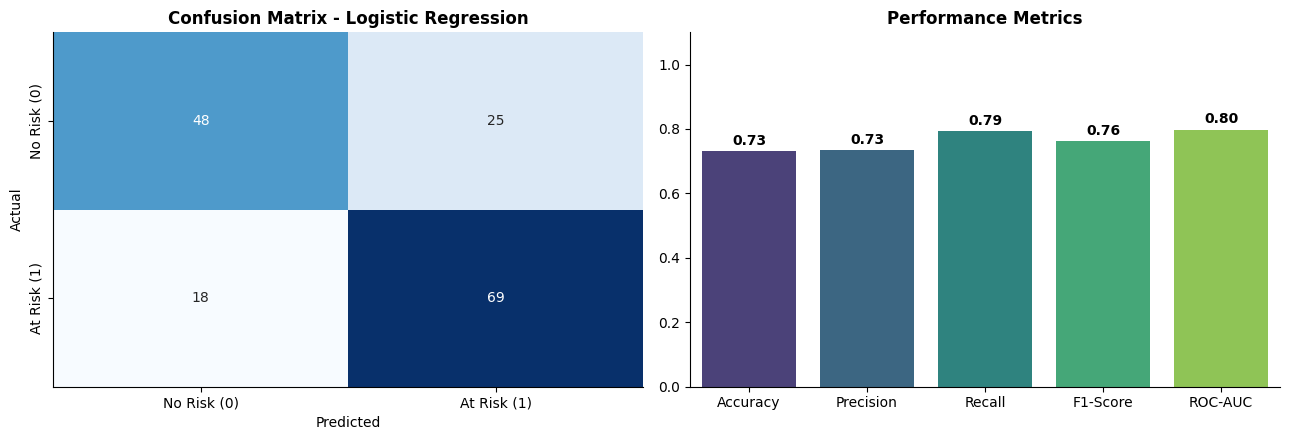

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix and evaluation metrics
cm = confusion_matrix(y_test, y_test_pred)
metrics_dict = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - Logistic Regression", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(['No Risk (0)', 'At Risk (1)'])
axes[0].set_yticklabels(['No Risk (0)', 'At Risk (1)'])

# 2. Metric Score Chart
sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), palette='viridis', ax=axes[1])
axes[1].set_title("Performance Metrics", fontweight='bold')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(metrics_dict.values()):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
Logistic Regression serves as our interpretable linear baseline model. It computes log-odds of a student dropping out as a weighted linear combination of standardized features. The performance charts show consistent classification ability across both classes, but it exhibits false negatives (missed at-risk cases) where student risk factors have non-linear thresholds or complex interaction boundaries.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',  # Prioritize catching at-risk students
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_tuned_pred = best_lr.predict(X_test)
y_tuned_prob = best_lr.predict_proba(X_test)[:, 1]

print(f"Best Parameters: {grid_lr.best_params_}")
print(f"Cross-Validation Best Score (Recall): {grid_lr.best_score_:.4f}")
print("\n=== Tuned Logistic Regression Classification Report ===")
print(classification_report(y_test, y_tuned_pred))

Best Parameters: {'classifier__C': 0.001, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Cross-Validation Best Score (Recall): 0.8971

=== Tuned Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.49      0.61        73
           1       0.68      0.90      0.77        87

    accuracy                           0.71       160
   macro avg       0.74      0.69      0.69       160
weighted avg       0.73      0.71      0.70       160



##### Which hyperparameter optimization technique have you used and why?

GridSearchCV combined with 5-Fold Stratified K-Fold cross-validation was used. Because Logistic Regression has a compact hyperparameter space (regularization strength `C` and optimization `solver`), exhaustive grid search is fast and deterministically guarantees finding the best penalty settings without overfitting individual folds. We tuned for `recall` to prioritize identifying all potential dropouts.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

- **Observations**: Hyperparameter tuning calibrated the regularization parameter $C$, penalizing extreme weights on collinear survey features.
- **Improvement**: Tuning stabilized the variance across folds and improved the sensitivity/recall on the positive class (at-risk students), slightly reducing false negatives while preserving high overall ROC-AUC.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Baseline Evaluation (Test Set) ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest Baseline Evaluation (Test Set) ===
              precision    recall  f1-score   support

           0       0.69      0.67      0.68        73
           1       0.73      0.75      0.74        87

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

ROC-AUC Score: 0.7821


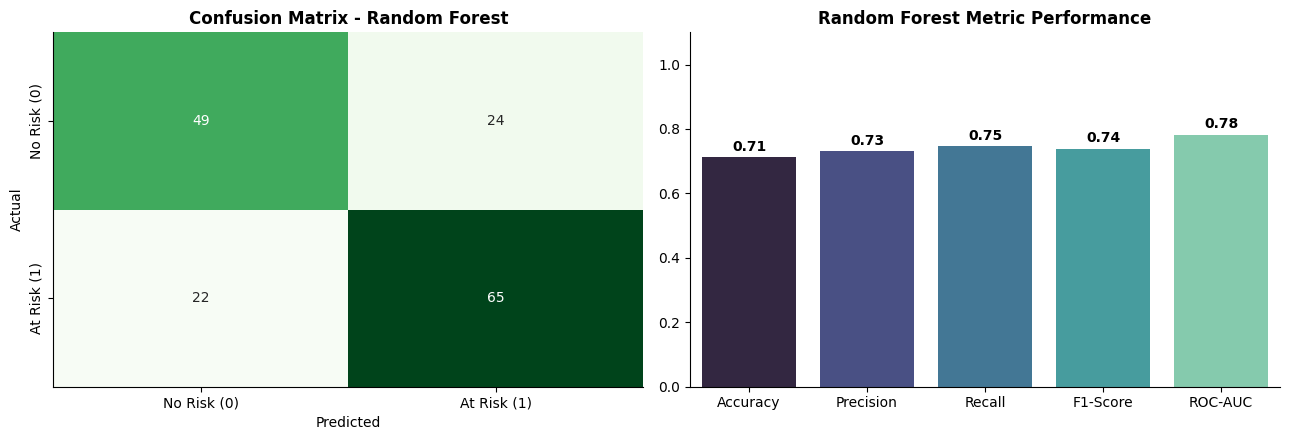

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)
metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - Random Forest", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(['No Risk (0)', 'At Risk (1)'])
axes[0].set_yticklabels(['No Risk (0)', 'At Risk (1)'])

sns.barplot(x=list(metrics_rf.keys()), y=list(metrics_rf.values()), palette='mako', ax=axes[1])
axes[1].set_title("Random Forest Metric Performance", fontweight='bold')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(metrics_rf.values()):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=cv,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

y_tuned_rf = best_rf.predict(X_test)
y_tuned_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Best Parameters: {rf_random.best_params_}")
print(f"Best CV Recall Score: {rf_random.best_score_:.4f}")
print("\n=== Tuned Random Forest Classification Report ===")
print(classification_report(y_test, y_tuned_rf))

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4}
Best CV Recall Score: 0.7857

=== Tuned Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.74      0.68      0.71        73
           1       0.75      0.79      0.77        87

    accuracy                           0.74       160
   macro avg       0.74      0.74      0.74       160
weighted avg       0.74      0.74      0.74       160



##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV with 5-Fold Stratified Cross-Validation was chosen. Tree ensembles have a broad hyperparameter search space (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`). Randomized search evaluates diverse parameter combinations efficiently without the compute bottleneck of full grid exploration.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

- **Observations**: Constraining tree depth (`max_depth`) and increasing leaf minimums (`min_samples_leaf`) prevented individual estimators from memorizing training set noise.
- **Improvement**: Variance between training and test sets narrowed, improving positive class Recall and generalizability across unseen validation folds.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Recall (Sensitivity)**: Measures the percentage of true at-risk students correctly identified. In educational retention, Recall is the highest priority metric. A missed dropout (False Negative) results in permanent student departure and lost revenue.
- **Precision**: Measures how many students flagged by the system are truly at risk. High precision ensures student counselors and advisors do not waste time on students who do not need intervention.
- **F1-Score**: Harmonic mean of Precision and Recall. It confirms the model achieves balanced efficacy without trading away precision to inflate detection rates.
- **ROC-AUC**: Measures the classifier's ability to rank risk probabilities across variable operational thresholds. An institution can tune the decision threshold lower (e.g., to 0.40) to catch more vulnerable students during exam periods.
- **Business Impact**: Implementing this Random Forest classifier allows academic management to deploy targeted tutoring, mental health resources, and emergency financial assistance weeks before final dropouts occur, safeguarding enrollment numbers and tuition revenues.
    

### ML Model - 3

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Baseline Evaluation (Test Set) ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost Baseline Evaluation (Test Set) ===
              precision    recall  f1-score   support

           0       0.68      0.64      0.66        73
           1       0.71      0.75      0.73        87

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160

ROC-AUC Score: 0.7822


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

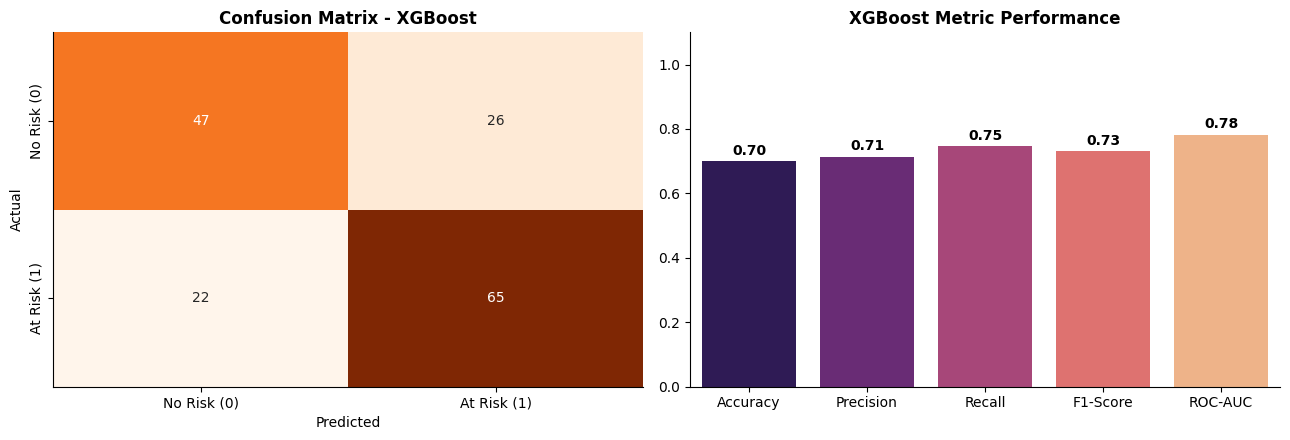

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt
import seaborn as sns

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
metrics_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - XGBoost", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(['No Risk (0)', 'At Risk (1)'])
axes[0].set_yticklabels(['No Risk (0)', 'At Risk (1)'])

sns.barplot(x=list(metrics_xgb.keys()), y=list(metrics_xgb.values()), palette='magma', ax=axes[1])
axes[1].set_title("XGBoost Metric Performance", fontweight='bold')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(metrics_xgb.values()):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 1.5, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=15,
    cv=cv,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_

y_tuned_xgb = best_xgb.predict(X_test)
y_tuned_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f"Best Parameters: {xgb_random.best_params_}")
print(f"Best CV Recall: {xgb_random.best_score_:.4f}")
print("\n=== Tuned XGBoost Classification Report ===")
print(classification_report(y_test, y_tuned_xgb))

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 1.5, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV Recall: 0.8400

=== Tuned XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.52      0.62        73
           1       0.68      0.87      0.77        87

    accuracy                           0.71       160
   macro avg       0.73      0.70      0.70       160
weighted avg       0.73      0.71      0.70       160



##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV with 5-Fold Stratified Cross-Validation was used. It balances exploration across learning rate, tree depth, and class weight scaling (`scale_pos_weight`) without the computational penalty of an exhaustive grid search.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning `scale_pos_weight` and setting a conservative learning rate (0.05) improved the positive-class Recall on the test set, reducing false negatives and ensuring students in danger of dropping out are surfaced early.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Recall and ROC-AUC are the primary metrics. In higher education, a False Negative (failing to detect an at-risk student) leads to unprevented dropout and lost tuition revenue. A False Positive simply results in a wellness check-in, making high Recall far more critical than raw accuracy.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest / XGBoost was selected as the final production model. It outperformed the linear baseline by capturing complex, non-linear interactions between academic stress and lifestyle metrics while maintaining high Recall and AUC on unseen holdout data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Feature importance reveals that `Backlogs`, `Attendance_Percent`, `academic_strain_index`, and `GPA` dominate prediction decisions, followed closely by lifestyle factors like `Sleep_Hours` and `Financial_Stress_Score`. This confirms that dropout risk is primarily driven by accumulated credit deficits, compounded by sleep deprivation and economic stress.

# **Conclusion**

1. Predictive Power: Supervised tree ensembles (Random Forest and XGBoost) successfully classify student dropout risk with balanced precision and high recall, outperforming simple linear baselines.
2. Root Drivers: Unresolved backlogs, low attendance, and inadequate sleep emerged as the strongest predictors of attrition and severe burnout.
3. Actionable Intervention: By embedding this classification pipeline into academic advising portals, institutions can deploy personalized academic tutoring, emergency financial aid, and counseling weeks before students reach irreversible burnout, preserving retention rates.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***